In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries Imported")

✅ Libraries Imported


In [56]:
import os
print(os.listdir('/users/admin/desktop/waterq-rp/code/r26-it-143/component2_water_quality/datasets'))

['pool_water_quality_augmented_dataset.csv']


In [57]:
df = pd.read_csv('/users/admin/desktop/waterq-rp//code/r26-it-143/component2_water_quality/datasets/pool_water_quality_augmented_dataset.csv')

print("✅ Dataset Loaded Successfully")
print(df.head())

✅ Dataset Loaded Successfully
             Timestamp    pH  Temperature  Chlorine  Turbidity    TDS  \
0  2026-04-01 00:00:00  7.66         27.5      1.82       1.22  387.5   
1  2026-04-01 00:00:30  7.44         26.7      1.95       1.12  380.0   
2  2026-04-01 00:01:00  7.48         27.2      1.95       5.52  385.1   
3  2026-04-01 00:01:30  7.54         27.4      1.82       1.51  429.0   
4  2026-04-01 00:02:00  7.42         27.5      1.86       0.91  364.1   

     Status  
0   WARNING  
1   WARNING  
2  CRITICAL  
3   WARNING  
4      SAFE  


In [58]:
# Features
X = df[['pH', 'Temperature', 'Chlorine', 'Turbidity', 'TDS']]

# Target
y = df['Status']

print("✅ Features and Target Selected")

✅ Features and Target Selected


In [59]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("✅ Label Encoding Complete")

print(label_encoder.classes_)

✅ Label Encoding Complete
['CRITICAL' 'SAFE' 'WARNING']


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print("✅ Data Split Complete")

print("Training Size:", len(X_train))
print("Testing Size:", len(X_test))

✅ Data Split Complete
Training Size: 800
Testing Size: 200


In [61]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("✅ Feature Scaling Complete")

✅ Feature Scaling Complete


In [62]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("✅ Model Training Complete")

✅ Model Training Complete


In [63]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("📊 MODEL ACCURACY")

print(f"Accuracy: {accuracy * 100:.2f}%")

📊 MODEL ACCURACY
Accuracy: 99.50%


In [64]:
print("📋 CLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

📋 CLASSIFICATION REPORT
              precision    recall  f1-score   support

    CRITICAL       1.00      0.67      0.80         3
        SAFE       1.00      1.00      1.00        52
     WARNING       0.99      1.00      1.00       145

    accuracy                           0.99       200
   macro avg       1.00      0.89      0.93       200
weighted avg       1.00      0.99      0.99       200



In [65]:
cm = confusion_matrix(y_test, y_pred)

print("🧩 CONFUSION MATRIX")

print(cm)

🧩 CONFUSION MATRIX
[[  2   0   1]
 [  0  52   0]
 [  0   0 145]]


In [66]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("📈 FEATURE IMPORTANCE")

print(importance)

📈 FEATURE IMPORTANCE
       Feature  Importance
3    Turbidity    0.873296
0           pH    0.076525
4          TDS    0.024257
2     Chlorine    0.013114
1  Temperature    0.012807


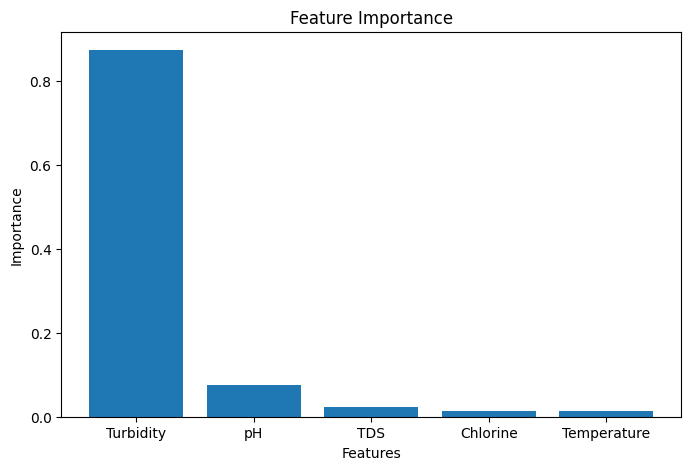

In [67]:
plt.figure(figsize=(8, 5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

In [68]:

joblib.dump(model, '../models/water_quality_model.pkl')

joblib.dump(scaler, '../models/scaler.pkl')

joblib.dump(label_encoder, '../models/label_encoder.pkl')

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


In [69]:
def predict_water_quality(
    ph,
    temperature,
    chlorine,
    turbidity,
    tds
):

    sample = np.array([
        [ph, temperature, chlorine, turbidity, tds]
    ])

    sample_scaled = scaler.transform(sample)

    prediction = model.predict(sample_scaled)

    status = label_encoder.inverse_transform(prediction)

    return status[0]

print("✅ Prediction Function Ready")

✅ Prediction Function Ready


In [70]:
#Test Prediction
result = predict_water_quality(
    ph=9,
    temperature=48,
    chlorine=7,
    turbidity=4.8,
    tds=500
)

print("🌊 WATER QUALITY PREDICTION")

print("Predicted Status:", result)

🌊 WATER QUALITY PREDICTION
Predicted Status: WARNING


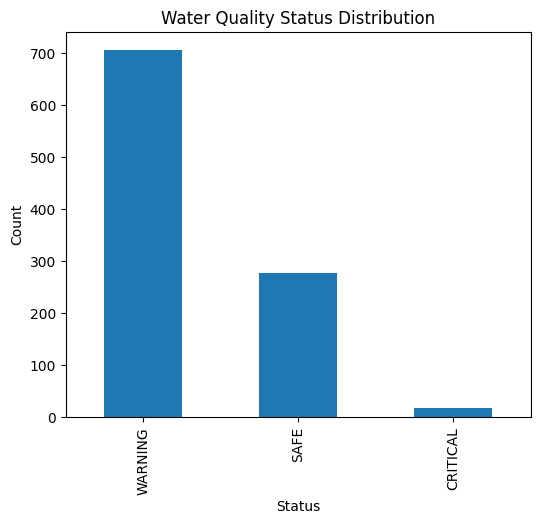

In [71]:
#Status Distribution Graph
plt.figure(figsize=(6,5))

df['Status'].value_counts().plot(
    kind='bar'
)

plt.title("Water Quality Status Distribution")

plt.xlabel("Status")

plt.ylabel("Count")

plt.show()

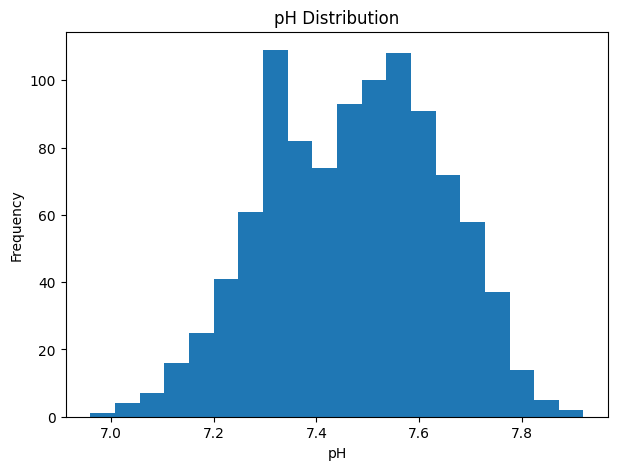

In [72]:
#pH Distribution
plt.figure(figsize=(7,5))

plt.hist(df['pH'], bins=20)

plt.title("pH Distribution")

plt.xlabel("pH")

plt.ylabel("Frequency")

plt.show()

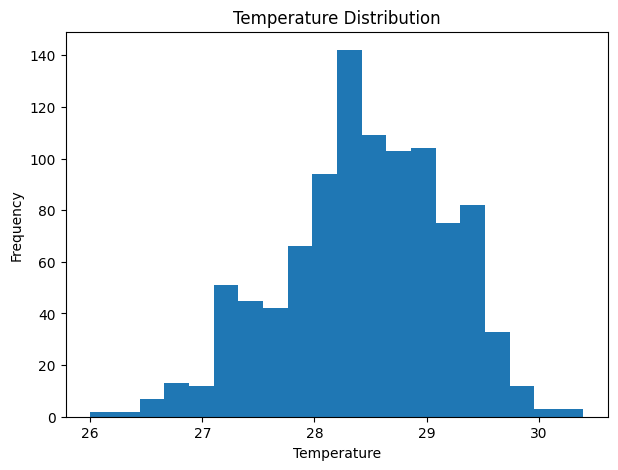

In [73]:
#Temperature Distribution
plt.figure(figsize=(7,5))

plt.hist(df['Temperature'], bins=20)

plt.title("Temperature Distribution")

plt.xlabel("Temperature")

plt.ylabel("Frequency")

plt.show()

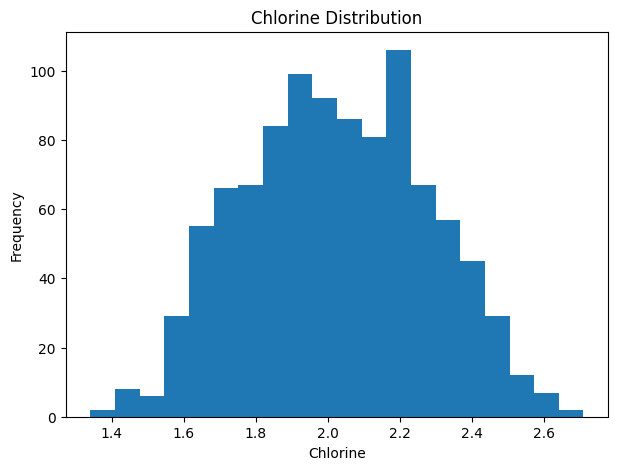

In [74]:
#Chlorine Distribution
plt.figure(figsize=(7,5))

plt.hist(df['Chlorine'], bins=20)

plt.title("Chlorine Distribution")

plt.xlabel("Chlorine")

plt.ylabel("Frequency")

plt.show()

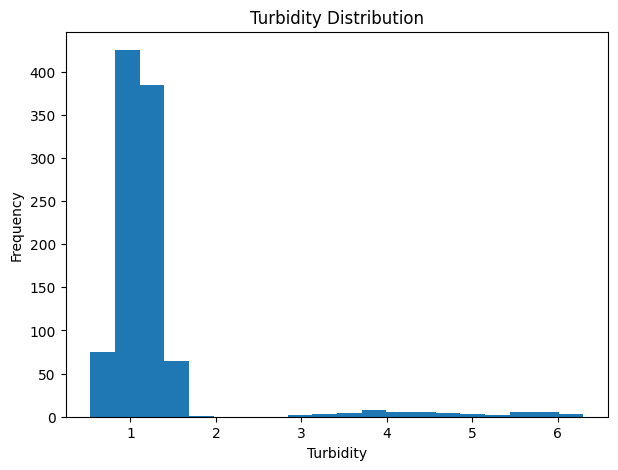

In [75]:
#Turbidity Distribution
plt.figure(figsize=(7,5))

plt.hist(df['Turbidity'], bins=20)

plt.title("Turbidity Distribution")

plt.xlabel("Turbidity")

plt.ylabel("Frequency")

plt.show()

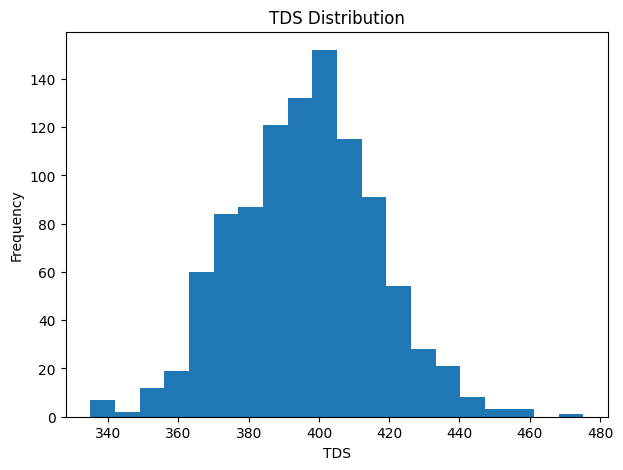

In [76]:
#TDS Distribution
plt.figure(figsize=(7,5))

plt.hist(df['TDS'], bins=20)

plt.title("TDS Distribution")

plt.xlabel("TDS")

plt.ylabel("Frequency")

plt.show()

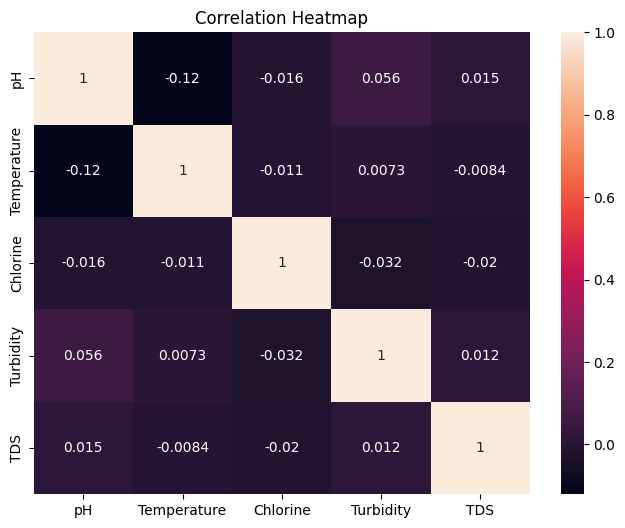

In [77]:
#Correlation Heatmap
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[['pH','Temperature','Chlorine','Turbidity','TDS']].corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

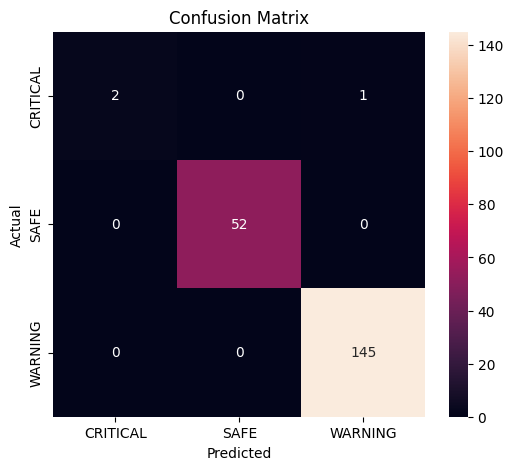

In [78]:
#Confusion Matrix Graph
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

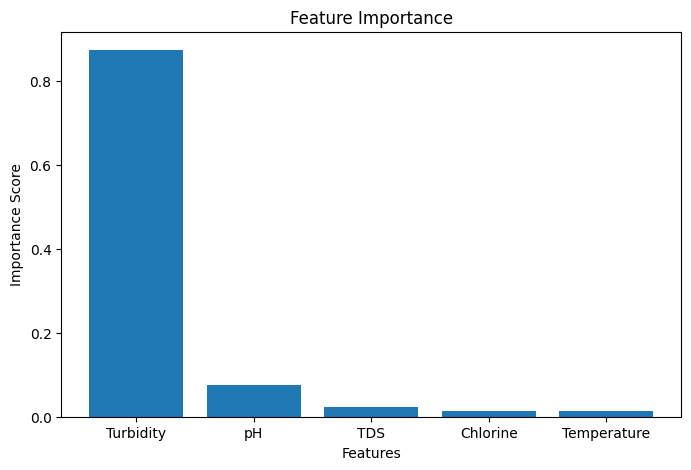

In [79]:
#Feature Importance Graph
plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.show()

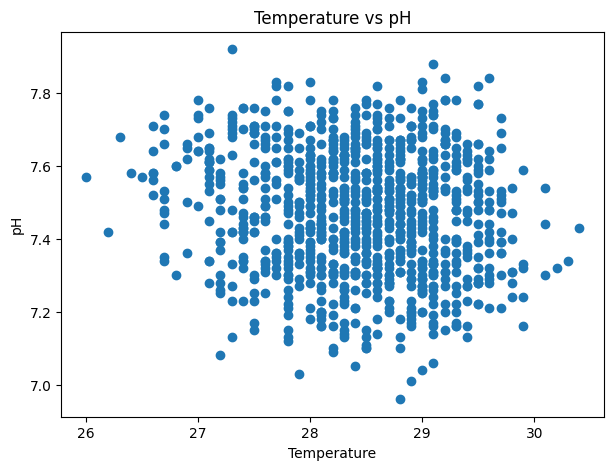

In [80]:
#Scatter Plot
plt.figure(figsize=(7,5))

plt.scatter(
    df['Temperature'],
    df['pH']
)

plt.title("Temperature vs pH")

plt.xlabel("Temperature")

plt.ylabel("pH")

plt.show()

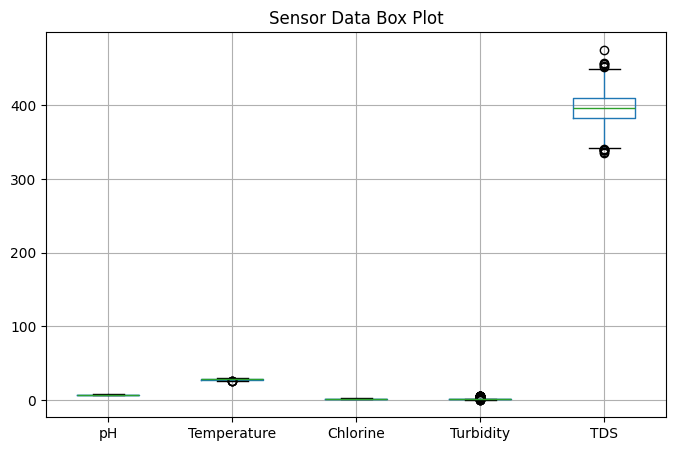

In [81]:
#Box Plot
plt.figure(figsize=(8,5))

df.boxplot(column=['pH','Temperature','Chlorine','Turbidity','TDS'])

plt.title("Sensor Data Box Plot")

plt.show()